# 📊 Task 4: Feature Encoding & Scaling
**Project:** Adult Income Prediction Preprocessing  
**Author:** [Your Name]  
**Date:** [Current Date]

---

## 🎯 Task Objective
The goal of this task is to prepare raw data for machine learning algorithms. Machine learning models require numerical input and generally perform better when features are on a similar scale. In this notebook, we will:
1.  **Identify** categorical and numerical features.
2.  **Encode** categorical text data into numerical formats (Label Encoding & One-Hot Encoding).
3.  **Scale** numerical features to standardize their range (StandardScaler).
4.  **Visualize** the impact of scaling on the data distribution.

## 📂 About the Dataset
We are using the **"Adult Income Dataset"** (also known as the Census Income dataset) from the UCI Machine Learning Repository.

* **Source:** 1994 US Census database.
* **Target Variable:** `income` (Determines if a person makes over $50K a year).
* **Rows:** ~32,000 observations.
* **Key Features:**
    * *Categorical:* Workclass, Education, Marital Status, Occupation, Relationship, Race, Sex, Native Country.
    * *Numerical:* Age, Fnlwgt (Final Weight), Capital Gain, Capital Loss, Hours per Week.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Load dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

# Drop missing values for this exercise to keep it clean
df.dropna(inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
# Identify Numerical and Categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Numerical Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical Features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


In [3]:
# --- A. Label Encoding (Target Variable) ---
# 'income' has two values: '<=50K' and '>50K'. Order matters (magnitude of income).
le = LabelEncoder()
df['income_encoded'] = le.fit_transform(df['income'])

print(f"Income Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- B. One-Hot Encoding (Nominal Variables) ---

# select a few categorical columns for One-Hot Encoding to keep the dataframe manageable
categorical_to_encode = ['workclass', 'marital-status', 'relationship', 'race', 'sex']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_to_encode, drop_first=True)

print("Shape after One-Hot Encoding:", df_encoded.shape)
df_encoded.head()

Income Mapping: {'<=50K': np.int64(0), '>50K': np.int64(1)}
Shape after One-Hot Encoding: (32561, 35)


,age,fnlwgt,education,education-num,occupation,capital-gain,capital-loss,hours-per-week,native-country,income,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,39,77516,Bachelors,13,Adm-clerical,2174,0,40,United-States,<=50K,...,True,False,False,False,False,False,False,False,True,True
1,50,83311,Bachelors,13,Exec-managerial,0,0,13,United-States,<=50K,...,False,False,False,False,False,False,False,False,True,True
2,38,215646,HS-grad,9,Handlers-cleaners,0,0,40,United-States,<=50K,...,True,False,False,False,False,False,False,False,True,True
3,53,234721,11th,7,Handlers-cleaners,0,0,40,United-States,<=50K,...,False,False,False,False,False,False,True,False,False,True
4,28,338409,Bachelors,13,Prof-specialty,0,0,40,Cuba,<=50K,...,False,False,False,False,True,False,True,False,False,False


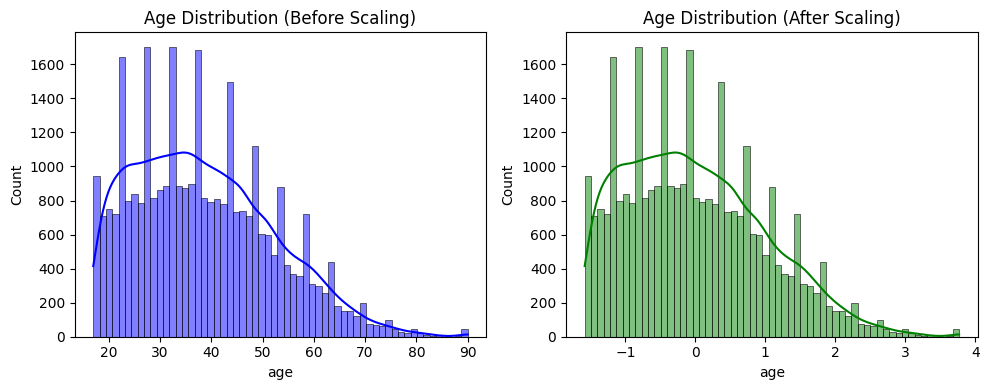


Statistics after Scaling:
      age  fnlwgt  capital-gain  capital-loss  hours-per-week
mean -0.0    -0.0           0.0           0.0            -0.0
std   1.0     1.0           1.0           1.0             1.0


In [4]:
# Features to scale
features_to_scale = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

# 1. Visualize BEFORE Scaling
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True, color='blue')
plt.title("Age Distribution (Before Scaling)")

# 2. Apply StandardScaler
scaler = StandardScaler()
df_encoded[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

# 3. Visualize AFTER Scaling
plt.subplot(1, 2, 2)
sns.histplot(df_encoded['age'], kde=True, color='green')
plt.title("Age Distribution (After Scaling)")

plt.tight_layout()
plt.show()

# Check statistics after scaling (Mean should be ~0, Std ~1)
print("\nStatistics after Scaling:")
print(df_encoded[features_to_scale].describe().loc[['mean', 'std']].round(2))

In [5]:
# Save the final processed dataframe
df_encoded.to_csv("adult_income_processed.csv", index=False)
print("Processed dataset saved successfully!")

Processed dataset saved successfully!


---

## 📝 Conclusion & Key Takeaways

In this task, we successfully transformed the raw "Adult Income" dataset into a format ready for model training (`adult_income_processed.csv`).

### 🔍 Summary of Outputs
1.  **Cleaned Data:** Missing values (represented as '?') were removed.
2.  **Encoded Features:**
    * The target variable `income` was converted to `0` (<=50K) and `1` (>50K) using **Label Encoding**.
    * Nominal variables like `workclass`, `race`, and `sex` were expanded into binary columns using **One-Hot Encoding**, preventing the model from assuming false rankings between categories.
3.  **Scaled Features:** Numerical columns (`age`, `capital-gain`, etc.) were normalized using **StandardScaler**. The mean of these features is now approx **0**, and the standard deviation is **1**.

### 💡 Impact on ML Algorithms
* **Why Scale?** Before scaling, `capital-gain` (values up to ~99k) would have dominated distance-based algorithms like **KNN** or **SVM** compared to `age` (values ~17-90). Now, all features contribute equally.
* **Why Encode?** The mathematical equations in algorithms like **Logistic Regression** can now process the categorical data that was previously text strings.

### 🚀 Next Steps
The dataset is now mathematically mature. The immediate next step is **Model Training**:
1.  Split data into **Train/Test** sets.
2.  Train a baseline model (e.g., Logistic Regression or Random Forest).
3.  Evaluate accuracy.